<a href="https://colab.research.google.com/github/juliandavidsilvaguzman-star/Week13_13/blob/main/Week13_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Week13_13 Implementación de un Autoencoder en una Red Denoising usando el dataset MNIST

# Preparación de Entorno y Datos
Importamos las librerías necesarias y preparamos el dataset MNIST para simular un escenario de reconstrucción de imágenes mediante la adición de ruido artificial.

In [ ]:
import numpy as np # Biblioteca para operaciones matriciales y manejo de arrays
import matplotlib.pyplot as plt # Biblioteca para visualización de datos y gráficos
from tensorflow.keras.datasets import mnist # Dataset de dígitos escritos a mano
from tensorflow.keras.layers import Input, Dense # Capas básicas para redes neuronales densas
from tensorflow.keras.models import Model # API funcional para construir modelos

print("Entorno preparado: Keras, NumPy y Matplotlib listos.")

Librerías importadas correctamente.


In [ ]:
# Cargar el conjunto de datos MNIST (60,000 imágenes de entrenamiento, 10,000 de prueba)
(x_train, _), (x_test, _) = mnist.load_data()

# Normalización: Escalamos los valores de los píxeles (0-255) al rango [0, 1]
# Esto ayuda a que el optimizador de la red neuronal converja más rápido.
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Aplanamiento (Flatten): Para el modelo inicial denso, convertimos la matriz 28x28 en un vector de 784 elementos.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print(f"Dimensiones de entrenamiento: {x_train.shape}")
print(f"Dimensiones de prueba: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Forma de entrenamiento: (60000, 784)
Forma de prueba: (10000, 784)


## Añadir ruido aleatorio a las imágenes de MNIST

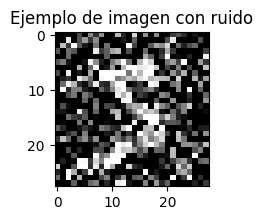

In [ ]:
# Definimos un factor de ruido (0.5 es un ruido moderado-alto)
noise_factor = 0.5

# Generamos ruido siguiendo una distribución normal (Gaussiana)
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# El ruido puede generar valores fuera de [0, 1]. Usamos clip para forzar el rango.
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Imágenes con ruido generadas y normalizadas.")

# Arquitectura Base de la Red Neuronal
Definimos un Autoencoder simple.
- **Encoder**: Reduce la dimensionalidad de la entrada (784 px) a una representación latente comprimida.
- **Decoder**: Intenta reconstruir la imagen original a partir del espacio latente.
Utilizaremos capas densas con activación `relu` y una capa de salida con `sigmoid` para mantener los valores de los píxeles entre 0 y 1.

### Conceptos Clave

1. **Autoencoder (El Sistema)**: Es la red completa. Su único trabajo es tomar algo (una imagen con ruido), entender qué es lo importante y tratar de recrearlo lo más parecido al original (sin el ruido).

2. **Encoder (El Compresor)**: Es como un resumidor experto. Toma los 784 píxeles de la imagen y los obliga a pasar por un embudo muy estrecho (el cuello de botella). Para lograrlo, tiene que tirar a la basura lo que no sirve (el ruido) y quedarse solo con la esencia del número.

3. **Decoder (El Reconstructor)**: Solo tiene el resumen del Encoder. Toma esa pequeña pieza de información comprimida y trata de expandirla para volver a dibujar la imagen completa de 784 píxeles. Como no sabe qué ruido había originalmente, solo dibuja el número limpio.

**En resumen:** El Encoder *aprende a ver* y el Decoder *aprende a dibujar*.

In [ ]:
# Configuración de la red densa
input_dim = 784  # Entrada: imagen aplanada
encoding_dim = 32 # Dimensión del cuello de botella (compresión de ~24.5 veces)

input_img = Input(shape=(input_dim,))

# ENCODER: Reduce de 784 -> 128 -> 32
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# DECODER: Reconstruye de 32 -> 128 -> 784
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded) # Sigmoid para salida entre [0, 1]

# Definición y compilación del modelo
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary() # Resumen visual de la arquitectura

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

### ¿Cómo interpretar la tabla?

La tabla que resume la red neuronal

1. **Layer (type)**: Es el nombre de la capa. Las capas del **Encoder** suelen llamarse `dense` y las del **Decoder** `dense_1`, `dense_2`, etc.
2. **Output Shape**: ¡Esta es la más importante!
   - Nota cómo empieza en `(None, 784)` (la imagen completa).
   - Luego baja a `(None, 128)` y finalmente a `(None, 32)`. ¡Aquí es donde ocurre la **compresión**!
   - Después el Decoder la sube de nuevo hasta `(None, 784)` para reconstruir la imagen.
   - El `None` significa que el modelo puede procesar cualquier cantidad de imágenes a la vez.
3. **Param # (Parámetros)**: Es el número de "neuronas conectadas".
   - Cada parámetro es un valor numérico que la red ajustará durante el entrenamiento.
   - **Regla de oro**: Cuantos más parámetros, más "inteligente" (o compleja) es la red, pero también requiere más memoria y tiempo.
4. **Total params**: La suma de todos los pesos que la red debe aprender para saber diferenciar entre el ruido aleatorio y la forma de un número.

### Estructura Esencial de un Autoencoder en Keras

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# 1. Definir el tamaño de la entrada y la compresión
input_size = 784
code_size = 32

# 2. Definir la entrada
input_img = Input(shape=(input_size,))

# 3. ENCODER: Capa que comprime los datos
encoded = Dense(code_size, activation='relu')(input_img)

# 4. DECODER: Capa que reconstruye los datos
decoded = Dense(input_size, activation='sigmoid')(encoded)

# 5. MODELO: Unir entrada y salida
basic_autoencoder = Model(input_img, decoded)

# 6. COMPILACIÓN
basic_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

print("Autoencoder básico creado con éxito.")
basic_autoencoder.summary()

Autoencoder básico creado con éxito.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

# Entrenar Modelo
Entrenamos el modelo utilizando las imágenes con ruido (`x_train_noisy`) como entrada y las imágenes originales (`x_train`) como objetivo. Esto enseña al autoencoder a ignorar el ruido y recuperar la señal original.

In [ ]:
# Configuración del entrenamiento
epochs = 10 # Define cuántas veces la red verá todo el dataset
batch_size = 256 # Define el número de muestras por actualización de gradiente

history = autoencoder.fit( # Inicia el proceso de entrenamiento
    x_train_noisy, x_train, # Entrada: imagen ruidosa, Objetivo: imagen original
    epochs=epochs, # Número de épocas
    batch_size=batch_size, # Tamaño del lote
    shuffle=True, # Mezcla los datos en cada época
    validation_data=(x_test_noisy, x_test) # Evalúa el modelo con datos no vistos durante el entrenamiento
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.2488 - val_loss: 0.1846
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1709 - val_loss: 0.1585
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1526 - val_loss: 0.1466
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1447 - val_loss: 0.1408
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1398 - val_loss: 0.1370
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1363 - val_loss: 0.1339
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1337 - val_loss: 0.1316
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1317 - val_loss: 0.1297
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1299 - val_loss: 0.1281
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1283 - val_loss: 0.1272


# Calcular Métricas y Presentar Resultados
Se evalua el rendimiento final en el conjunto de prueba y analizamos la evolución de la pérdida.

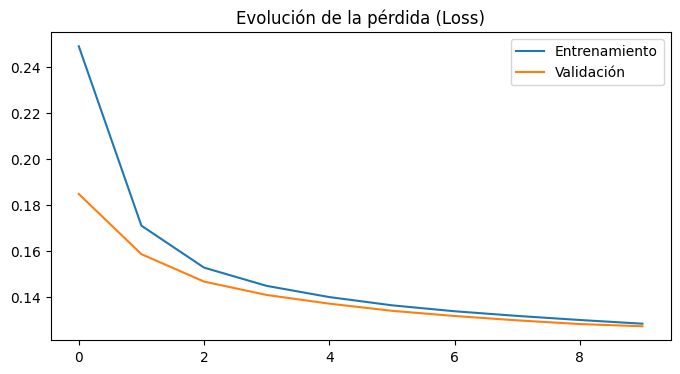

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


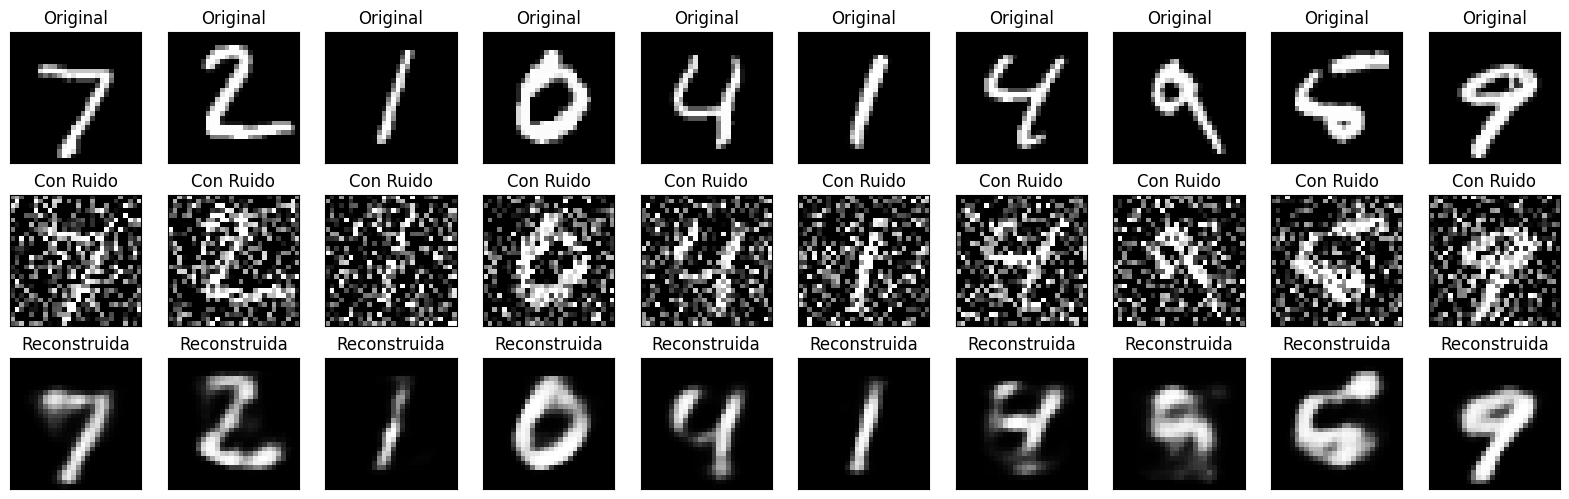

In [ ]:
# 5. Gráficos y Visualizaciones

# Gráfico de pérdida
plt.figure(figsize=(8, 4)) # Crea la figura
plt.plot(history.history['loss'], label='Entrenamiento') # Grafica la pérdida de entrenamiento
plt.plot(history.history['val_loss'], label='Validación') # Grafica la pérdida de validación
plt.title('Evolución de la pérdida (Loss)') # Título del gráfico
plt.legend() # Muestra la leyenda
plt.show() # Despliega el gráfico

# Predicción (reconstrucción)
decoded_imgs = autoencoder.predict(x_test_noisy) # Pasa las imágenes ruidosas por el modelo para limpiarlas

# Visualización comparativa
n = 10 # Cantidad de imágenes a mostrar
plt.figure(figsize=(20, 6)) # Define tamaño de la cuadrícula de imágenes
for i in range(n): # Itera sobre las primeras 10 imágenes
    # Original
    ax = plt.subplot(3, n, i + 1) # Define posición en la primera fila
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray') # Muestra original
    plt.title("Original") # Título
    ax.get_xaxis().set_visible(False) # Oculta eje X
    ax.get_yaxis().set_visible(False) # Oculta eje Y

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n) # Define posición en la segunda fila
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray') # Muestra ruidosa
    plt.title("Con Ruido") # Título
    ax.get_xaxis().set_visible(False) # Oculta eje X
    ax.get_yaxis().set_visible(False) # Oculta eje Y

    # Reconstrucción
    ax = plt.subplot(3, n, i + 1 + 2*n) # Define posición en la tercera fila
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray') # Muestra resultado del autoencoder
    plt.title("Reconstruida") # Título
    ax.get_xaxis().set_visible(False) # Oculta eje X
    ax.get_yaxis().set_visible(False) # Oculta eje Y
plt.show() # Despliega la comparativa final

### Visualización: Original vs. Reconstrucción
En esta sección comparamos las imágenes limpias originales contra el resultado obtenido por el modelo.

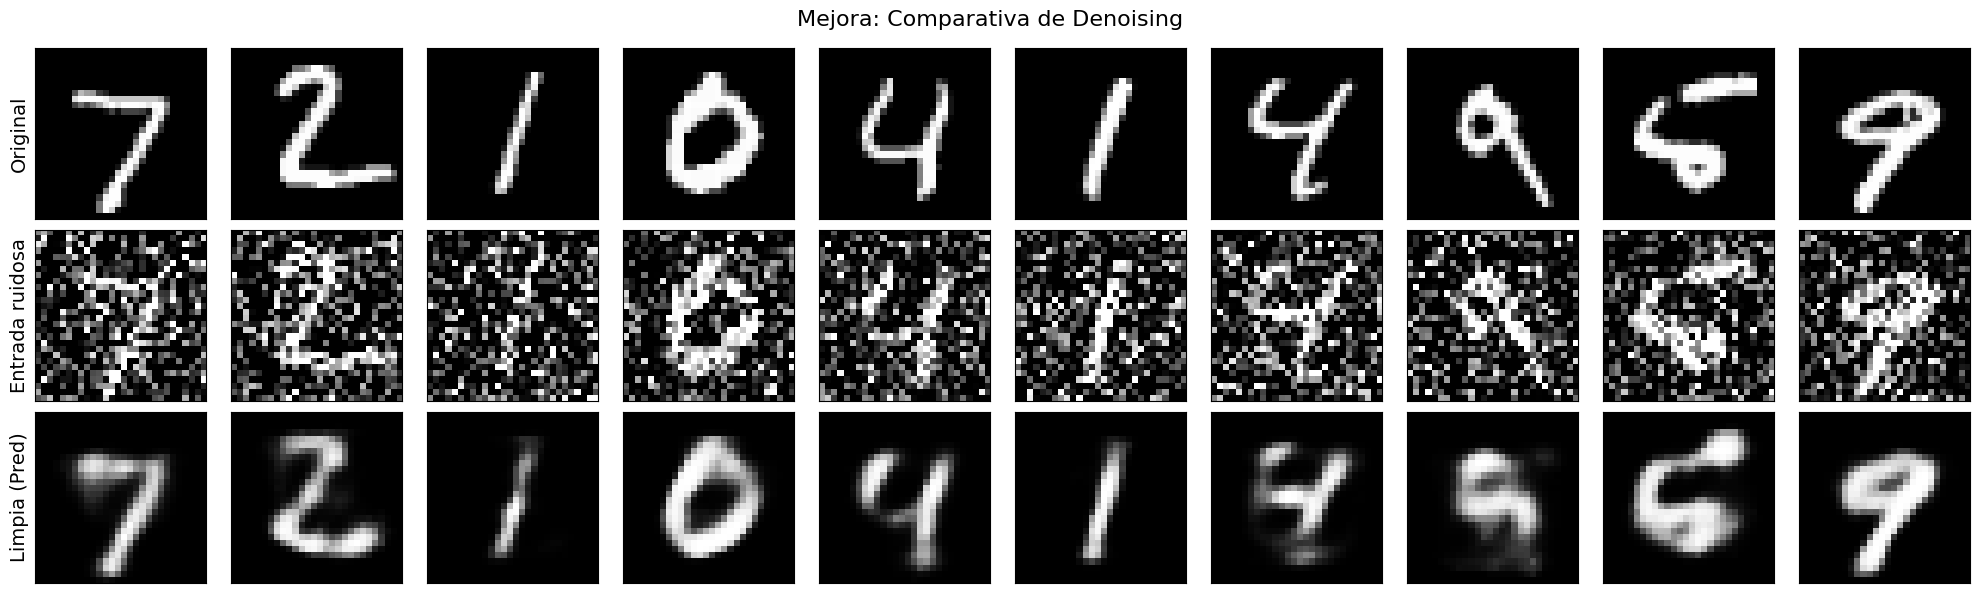

In [ ]:
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
n_imagenes = 10
# ---------------------

try:
    # Aumentamos el alto de la figura para 3 filas
    plt.figure(figsize=(2 * n_imagenes, 6))

    for i in range(n_imagenes):
        # 1. Mostrar Original (Arriba)
        ax = plt.subplot(3, n_imagenes, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel("Original", size=14)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_ticks([])

        # 2. Mostrar Ruidosa (Medio)
        ax = plt.subplot(3, n_imagenes, i + 1 + n_imagenes)
        plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel("Entrada ruidosa", size=14)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_ticks([])

        # 3. Mostrar Reconstrucción (Abajo)
        ax = plt.subplot(3, n_imagenes, i + 1 + 2 * n_imagenes)
        plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel("Limpia (Pred)", size=14)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_ticks([])

    plt.suptitle("Mejora: Comparativa de Denoising", size=16)
    plt.tight_layout()
    plt.show()
except NameError:
    print("Error: Asegúrate de ejecutar todas las celdas anteriores.")

# Mejora Avanzada: Autoencoder Convolucional
Este modelo utiliza capas `Conv2D` y `UpSampling2D` para procesar las imágenes en su formato original de 28x28, lo que permite una reconstrucción de mayor calidad.

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Dropout, Input

# Para modelos convolucionales, necesitamos la forma (Ancho, Alto, Canales)
x_train_conv = x_train.reshape(-1, 28, 28, 1)
x_test_conv = x_test.reshape(-1, 28, 28, 1)
x_train_noisy_conv = x_train_noisy.reshape(-1, 28, 28, 1)
x_test_noisy_conv = x_test_noisy.reshape(-1, 28, 28, 1)

input_img = Input(shape=(28, 28, 1))

# ENCODER CONVOLUCIONAL
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img) # Detecta patrones espaciales
x = MaxPooling2D((2, 2), padding='same')(x) # Reduce dimensiones a la mitad
x = Dropout(0.25)(x) # Apaga neuronas aleatoriamente para evitar overfitting
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x) # Dimensión final del cuello de botella: (7, 7, 32)

# DECODER CONVOLUCIONAL
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x) # Agranda la imagen (de 7x7 a 14x14)
x = Dropout(0.25)(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x) # Agranda la imagen (de 14x14 a 28x28)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_conv = Model(input_img, decoded)
autoencoder_conv.compile(optimizer='adam', loss='binary_crossentropy')

print("Arquitectura Convolucional con Dropout lista.")

Modelo convolucional con Dropout compilado.


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Re-entrenar el modelo convolucional CON Dropout
history_conv_dropout = autoencoder_conv.fit(
    x_train_noisy_conv, x_train_conv,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_conv, x_test_conv)
)

# Realizar nuevas predicciones
decoded_imgs_dropout = autoencoder_conv.predict(x_test_noisy_conv)

print("Entrenamiento finalizado con capas de Dropout.")

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 151s 316ms/step - loss: 0.1765 - val_loss: 0.1129
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 300ms/step - loss: 0.1165 - val_loss: 0.1051
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 146s 309ms/step - loss: 0.1108 - val_loss: 0.1022
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 300ms/step - loss: 0.1082 - val_loss: 0.1008
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 308ms/step - loss: 0.1066 - val_loss: 0.0997
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 301ms/step - loss: 0.1053 - val_loss: 0.0990
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 305ms/step - loss: 0.1044 - val_loss: 0.0985
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 297ms/step - loss: 0.1037 - val_loss: 0.0977
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 148s 310ms/step - loss: 0.1031 - val_loss: 0.0974
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 297ms/step - loss: 0.1026 - val_loss: 0.0970
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
Entrenamiento finalizado con capas de Dropout.


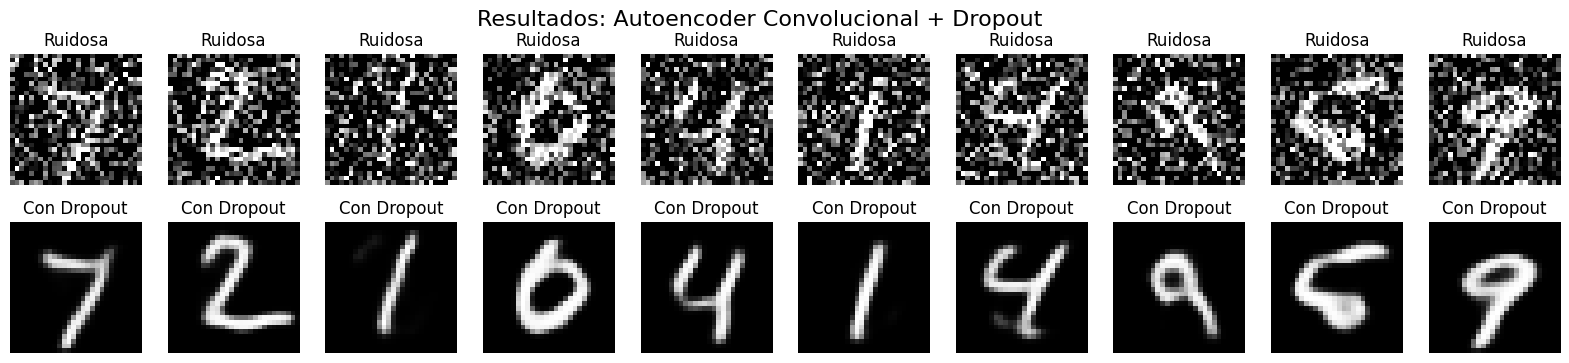

In [ ]:
# Visualizar la mejora con Dropout
plt.figure(figsize=(20, 4))
for i in range(10):
    # Entrada ruidosa
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_noisy_conv[i].reshape(28, 28), cmap='gray')
    plt.title("Ruidosa")
    ax.axis('off')

    # Reconstrucción con Dropout
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(decoded_imgs_dropout[i].reshape(28, 28), cmap='gray')
    plt.title("Con Dropout")
    ax.axis('off')

plt.suptitle("Resultados: Autoencoder Convolucional + Dropout", size=16)
plt.show()

### Comparativa Final de Modelos
Visualizamos la evolución de la pérdida de validación para comparar el impacto del Dropout y la arquitectura convolucional.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Modelo 1: Simple (Dense)
if 'history' in globals():
    plt.plot(history.history['val_loss'], label='1. Simple (Dense)', linestyle=':')

# Modelo 2: Convolucional (CNN)
if 'history_conv' in globals():
    plt.plot(history_conv.history['val_loss'], label='2. Convolucional (CNN)', linestyle='--')

# Modelo 3: Convolucional + Dropout
if 'history_conv_dropout' in globals():
    plt.plot(history_conv_dropout.history['val_loss'], label='3. CNN + Dropout', linewidth=3)

plt.title('Comparativa de Modelos: Pérdida en Validación')
plt.xlabel('Épocas')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

### Comparativa Final de Modelos
Visualizamos la evolución de la pérdida de validación para comparar el impacto del Dropout y la arquitectura convolucional.

In [ ]:
plt.figure(figsize=(12, 6))

# Modelo 1: Simple (Dense)
plt.plot(history.history['val_loss'], label='1. Simple (Dense)', linestyle=':')

# Modelo 2: Convolucional (CNN)
plt.plot(history_conv.history['val_loss'], label='2. Convolucional (CNN)', linestyle='--')

# Modelo 3: Convolucional + Dropout
plt.plot(history_conv_dropout.history['val_loss'], label='3. CNN + Dropout', linewidth=3)

plt.title('Comparativa de Modelos: Pérdida en Validación')
plt.xlabel('Épocas')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

### Comparativa Visual Final: Todos los Modelos
En esta celda comparamos una muestra de imágenes procesadas por las tres arquitecturas desarrolladas.

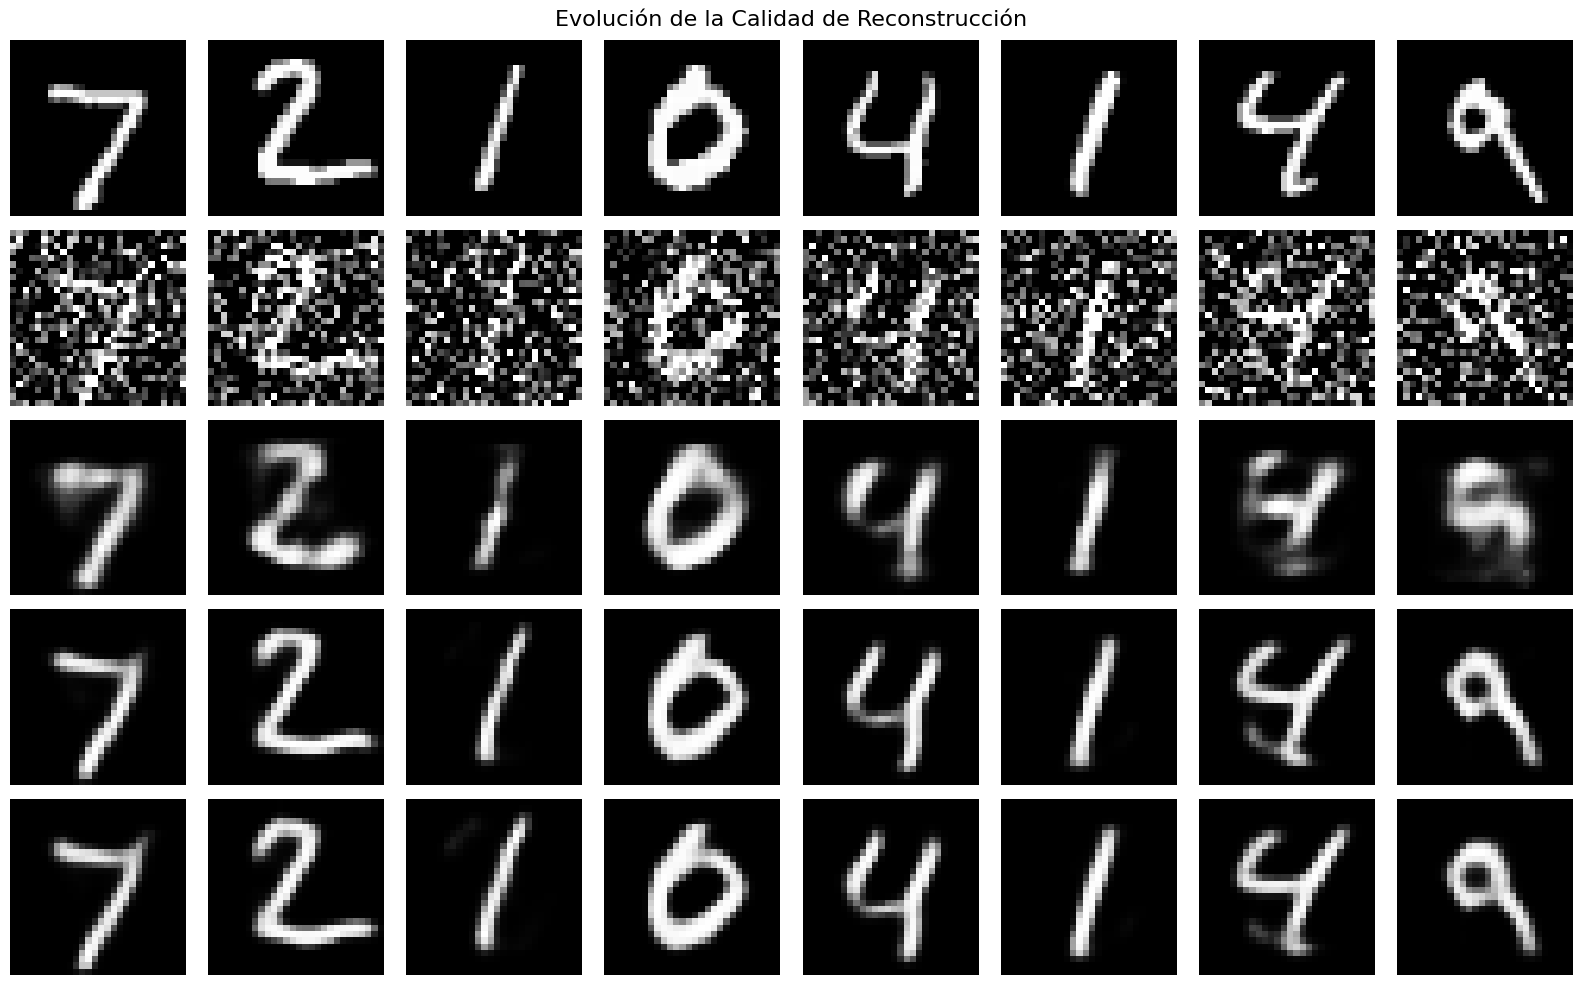

In [ ]:
import matplotlib.pyplot as plt

n = 8
plt.figure(figsize=(16, 10))

for i in range(n):
    # 1. Original
    ax = plt.subplot(5, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    if i == 0: plt.ylabel("Original", size=12)
    ax.axis('off')

    # 2. Con Ruido
    ax = plt.subplot(5, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    if i == 0: plt.ylabel("Con Ruido", size=12)
    ax.axis('off')

    # 3. Reconstrucción Simple (Dense)
    ax = plt.subplot(5, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    if i == 0: plt.ylabel("Simple", size=12)
    ax.axis('off')

    # 4. Reconstrucción CNN
    ax = plt.subplot(5, n, i + 1 + 3*n)
    if 'decoded_imgs_conv' in globals():
        plt.imshow(decoded_imgs_conv[i].reshape(28, 28), cmap='gray')
    if i == 0: plt.ylabel("CNN", size=12)
    ax.axis('off')

    # 5. Reconstrucción CNN + Dropout
    ax = plt.subplot(5, n, i + 1 + 4*n)
    if 'decoded_imgs_dropout' in globals():
        plt.imshow(decoded_imgs_dropout[i].reshape(28, 28), cmap='gray')
    if i == 0: plt.ylabel("CNN + Dropout", size=12)
    ax.axis('off')

plt.suptitle("Evolución de la Calidad de Reconstrucción", size=16)
plt.tight_layout()
plt.show()

### Prueba de Robustez: Ruido Extremo
Evaluamos el modelo con un nivel de ruido superior al de entrenamiento (`noise_factor = 0.75`) para ver su capacidad de generalización.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generar ruido extremo (0.75 en lugar de 0.5)
extreme_noise_factor = 0.75
x_test_extreme_noisy = x_test_conv + extreme_noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_conv.shape)
x_test_extreme_noisy = np.clip(x_test_extreme_noisy, 0., 1.)

# 2. Predecir con el modelo de Dropout
decoded_extreme = autoencoder_conv.predict(x_test_extreme_noisy)

# 3. Visualizar resultados
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Imagen con ruido extremo
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_extreme_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Extremo")
    ax.axis('off')

    # Reconstrucción
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_extreme[i].reshape(28, 28), cmap='gray')
    plt.title("Recuperado")
    ax.axis('off')

plt.suptitle(f"Denoising con Ruido Extremo (Factor: {extreme_noise_factor})", size=16)
plt.show()

### Análisis de Distribución de Píxeles
Comparamos los histogramas de intensidad para observar cómo el autoencoder recupera la estructura bimodal (blanco/negro) del dataset original.

In [ ]:
import matplotlib.pyplot as plt

# Verificamos que las variables existan antes de graficar
if 'x_test_extreme_noisy' in globals() and 'decoded_extreme' in globals():
    plt.figure(figsize=(15, 5))

    # Histograma de la imagen original
    plt.subplot(1, 3, 1)
    plt.hist(x_test.flatten(), bins=50, color='blue', alpha=0.7)
    plt.title('Distribución Original')
    plt.xlabel('Intensidad de píxel')
    plt.ylabel('Frecuencia')

    # Histograma de la imagen con ruido
    plt.subplot(1, 3, 2)
    plt.hist(x_test_extreme_noisy.flatten(), bins=50, color='red', alpha=0.7)
    plt.title('Distribución con Ruido (0.75)')
    plt.xlabel('Intensidad de píxel')

    # Histograma de la reconstrucción
    plt.subplot(1, 3, 3)
    plt.hist(decoded_extreme.flatten(), bins=50, color='green', alpha=0.7)
    plt.title('Distribución Reconstruida')
    plt.xlabel('Intensidad de píxel')

    plt.tight_layout()
    plt.show()
else:
    print("Error: La variable 'x_test_extreme_noisy' no existe. Por favor, ejecuta la celda de 'Prueba de Robustez' antes de esta.")

Error: La variable 'x_test_extreme_noisy' no existe. Por favor, ejecuta la celda de 'Prueba de Robustez' antes de esta.


### Cálculo de Métricas de Error (MSE)
Calculamos el Error Cuadrático Medio para cuantificar la calidad de la reconstrucción frente al ruido extremo.

In [ ]:
import numpy as np

# Prueba de Robustez con Ruido Extremo
extreme_noise_factor = 0.75
x_test_extreme_noisy = x_test_conv + extreme_noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_conv.shape)
x_test_extreme_noisy = np.clip(x_test_extreme_noisy, 0., 1.)

# Inferencia: El modelo intenta limpiar el ruido extremo
decoded_extreme = autoencoder_conv.predict(x_test_extreme_noisy)

# Métrica MSE (Mean Squared Error): Promedio del cuadrado de la diferencia entre píxeles
def calculate_mse(target, predicted):
    return np.mean(np.square(target - predicted))

mse_noisy = calculate_mse(x_test_conv, x_test_extreme_noisy) # Error antes de la red
mse_recovered = calculate_mse(x_test_conv, decoded_extreme)   # Error después de la red

print(f"MSE Original vs Ruidosa: {mse_noisy:.4f}")
print(f"MSE Original vs Recuperada: {mse_recovered:.4f}")
print(f"\nReducción del error: {((mse_noisy - mse_recovered) / mse_noisy * 100):.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
MSE entre Original y Ruidosa (0.75): 0.1954
MSE entre Original y Reconstruida:    0.0251

Mejora relativa: 87.13%


In [ ]:
# Entrenar el modelo convolucional
history_conv = autoencoder_conv.fit(
    x_train_noisy_conv, x_train_conv,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_conv, x_test_conv)
)

# Realizar predicciones con el nuevo modelo
decoded_imgs_conv = autoencoder_conv.predict(x_test_noisy_conv)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 285ms/step - loss: 0.1649 - val_loss: 0.1167
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 285ms/step - loss: 0.1138 - val_loss: 0.1091
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 292ms/step - loss: 0.1084 - val_loss: 0.1054
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 280ms/step - loss: 0.1051 - val_loss: 0.1028
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 285ms/step - loss: 0.1027 - val_loss: 0.1011
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 288ms/step - loss: 0.1010 - val_loss: 0.0995
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 135s 288ms/step - loss: 0.0999 - val_loss: 0.0985
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 286ms/step - loss: 0.0989 - val_loss: 0.0980
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 286ms/step - loss: 0.0983 - val_loss: 0.0975
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 294ms/step - loss: 0.0976 - val_loss: 0.0966
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


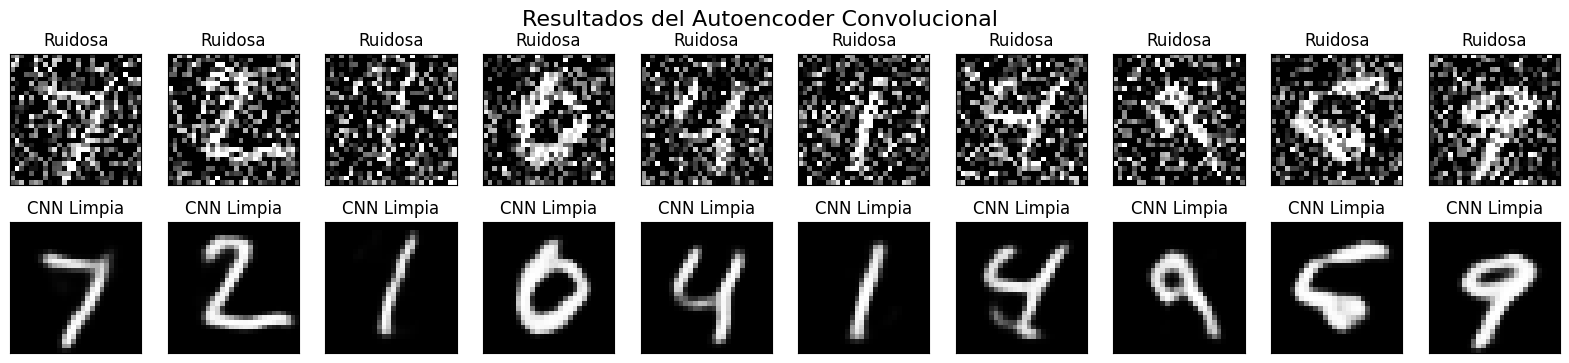

In [ ]:
# Visualización de resultados del modelo Convolucional
plt.figure(figsize=(20, 4))
for i in range(10):
    # Entrada ruidosa
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_noisy_conv[i].reshape(28, 28), cmap='gray')
    plt.title("Ruidosa")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstrucción CNN
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(decoded_imgs_conv[i].reshape(28, 28), cmap='gray')
    plt.title("CNN Limpia")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.suptitle("Resultados del Autoencoder Convolucional", size=16)
plt.show()

### Comparativa de Rendimiento
En esta sección comparamos cómo aprendieron ambos modelos. El modelo convolucional suele alcanzar una pérdida (loss) menor gracias a su capacidad de entender la estructura 2D de los números.

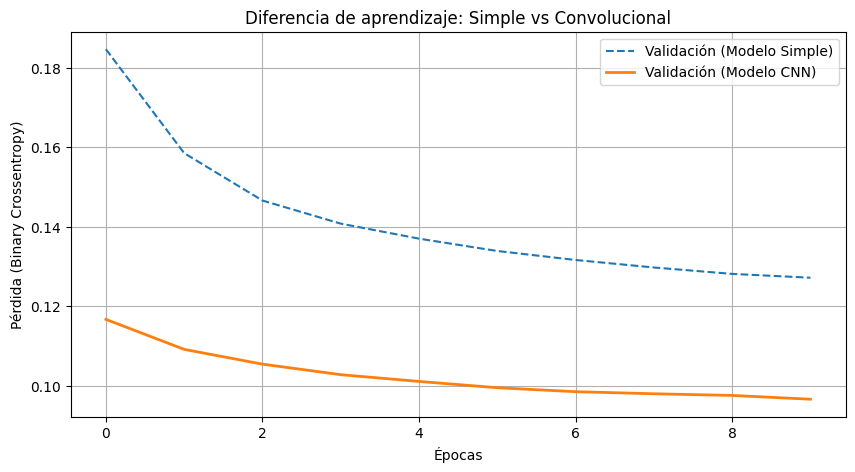

In [ ]:
plt.figure(figsize=(10, 5))

# Pérdida del modelo Dense
plt.plot(history.history['val_loss'], label='Validación (Modelo Simple)', linestyle='--')

# Pérdida del modelo CNN
plt.plot(history_conv.history['val_loss'], label='Validación (Modelo CNN)', linewidth=2)

plt.title('Diferencia de aprendizaje: Simple vs Convolucional')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

# Conclusiones

### Comportamiento del Modelo
Durante el entrenamiento, observamos que la **función de pérdida (Loss)** disminuye tanto en los datos de entrenamiento como en los de validación. Esto indica que la red está aprendiendo patrones generales y no simplemente memorizando las imágenes (evitando el *overfitting*). El autoencoder utiliza el **cuello de botella (bottleneck)** para obligar a la red a comprimir la información, quedándose solo con las características esenciales del número y descartando el ruido.

### Calidad de Reconstrucción
Aunque la salida puede verse ligeramente más borrosa que la original, la calidad es notable porque el modelo logra eliminar el factor de ruido del 50%. La activación `sigmoid` en la última capa garantiza que los píxeles se mantengan en el rango [0, 1], mientras que la pérdida `binary_crossentropy` es efectiva para comparar la similitud estadística entre la imagen original y la reconstruida.

### Aplicaciones Reales de los Autoencoders
Esta tecnología no solo sirve para limpiar imágenes de números; en la industria se utiliza para:
1.  **Denoising (Eliminación de Ruido):** Limpiar grabaciones de audio o imágenes médicas (como Rayos X) con interferencias.
2.  **Detección de Anomalías:** Si una red se entrena solo con datos "normales", cualquier dato con un error de reconstrucción muy alto puede identificarse como un fallo (ej. transacciones bancarias fraudulentas).
3.  **Compresión de Datos:** Reducir el tamaño de archivos manteniendo la información semántica más importante.
4.  **Generación de Datos:** Variantes como los VAE (Variational Autoencoders) se usan para crear caras o paisajes realistas desde cero.